# Vision Transformers

The Transformer is a family of neural network architectures that originated in NLP and was later adapted to computer vision. Unlike convolutional networks, transformers do not assume any specific spatial structure in their input, which lets them learn more general dependencies between input elements. This is one of the key reasons Vision Transformers (ViTs) have become a strong alternative to CNNs. At the same time, ViTs are known to be **data-hungry**, and training them well is non-trivial.

In this seminar we will:

1. walk through the main building blocks of a Vision Transformer,
2. assemble them into a working `VisionTransformer` model, and
3. discuss the ingredients that make ViT training actually work in practice (augmentations, regularization, learning-rate schedules).

The material here will be useful for the upcoming homework, where you will train a Vision Transformer on **CIFAR-10**.

> **How to work with this notebook.** Every cell that contains `# YOUR CODE` (or `...`) is a **task for you**. Read the explanation above the cell, fill in the missing pieces, and run the cell — there is usually a sanity check right after it.

In [ ]:
import torch
from torch import nn

## How to code your transformer

As mentioned above, the Transformer was originally designed for NLP, where the typical input is an ordered sequence of tokens (words or sub-words). To apply it to images, we need to express an image as a sequence of tokens as well. A Vision Transformer is therefore composed of the following main blocks:

1. **Tokenizer** — splits an image into non-overlapping patches and projects each patch into an embedding vector (a *token*).
2. **Positional embeddings** — encode the spatial position of each token, since attention itself is permutation-invariant.
3. **Class token** — a learnable token prepended to the sequence; its final hidden state is used as the global image representation.
4. **Transformer encoder** — a stack of blocks, each containing Multi-Head Self-Attention, an MLP, residual connections and Layer Normalization.
5. **Classification head** — an MLP (often just a single linear layer) on top of the class-token representation that predicts the class logits.

We will implement each block separately, then put everything together into a `VisionTransformer` module.

### Tokenizer

The tokenizer takes an input image $x \in \mathbb{R}^{C \times H \times W}$, splits it into non-overlapping patches of size $p \times p$, flattens each patch and applies a linear projection of dimension `embedding_dim`. The output is a tensor of shape `(B, N, D)`, where $N = (H/p) \cdot (W/p)$ is the number of patches and $D$ is the embedding dimension.

There are several ways to implement this. The cleanest one is to use a single `nn.Conv2d` with `kernel_size = stride = p`: this is mathematically equivalent to "split into patches + flatten + linear projection", but it is a single fused operation.

**Task.** Inside the `Tokenizer` module below, instantiate `self.conv` so that:

* it takes `n_input_channels` input channels and produces `embedding_dim` output channels,
* its kernel size and stride are both equal to `kernel_size = input_height // output_height`.

After the convolution we flatten the spatial dimensions and transpose so that the token dimension comes before the embedding dimension.

In [ ]:
class Tokenizer(nn.Module):
    """Splits an image into non-overlapping patches and projects them into tokens."""

    def __init__(
        self, input_height, input_width,
        output_height, output_width,
        n_input_channels, embedding_dim,
    ):
        super().__init__()

        assert input_height % output_height == 0, (
            f"input_height ({input_height}) must be divisible by output_height ({output_height})"
        )
        assert input_width % output_width == 0, (
            f"input_width ({input_width}) must be divisible by output_width ({output_width})"
        )

        kernel_size = input_height // output_height
        assert kernel_size == input_width // output_width, (
            "patches must be square: input_height/output_height must equal input_width/output_width"
        )

        # YOUR CODE: define a Conv2d that maps (B, n_input_channels, H, W)
        # to (B, embedding_dim, output_height, output_width).
        # Hint: use kernel_size == stride == kernel_size; no padding.
        self.conv = nn.Conv2d(...)

        self.flattener = nn.Flatten(2, 3)

    def forward(self, x):
        # (B, D, H', W') -> (B, D, N) -> (B, N, D)
        return self.flattener(self.conv(x)).transpose(-2, -1)


In [ ]:
tokenizer = Tokenizer(
    input_height=32, input_width=32,
    output_height=16, output_width=16,
    n_input_channels=3, embedding_dim=64,
)
dummy_batch = torch.zeros((2, 3, 32, 32))
tokenizer_result = tokenizer(dummy_batch)
assert tokenizer_result.shape == (2, 16 * 16, 64), tokenizer_result.shape
print("tokenizer output:", tokenizer_result.shape)  # (B, N, D)

### Transformer encoder

A Transformer encoder block consists of two sub-blocks: **Multi-Head Self-Attention** and an **MLP**, each preceded by Layer Normalization (the *pre-norm* variant) and wrapped in a residual connection:

$$
\begin{aligned}
x &\leftarrow x + \mathrm{DropPath}\bigl(\mathrm{MHSA}(\mathrm{LN}(x))\bigr), \\
x &\leftarrow x + \mathrm{DropPath}\bigl(\mathrm{MLP}(\mathrm{LN}(x))\bigr).
\end{aligned}
$$

Let's first look at each component separately.

#### Multi-head attention

Scaled dot-product attention is defined as

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right) V .
$$

**Multi-head attention** splits $Q$, $K$, $V$ along the embedding dimension into $h$ heads, applies attention independently in each head, and concatenates the results. This lets the model attend to information from different representation sub-spaces in parallel.

PyTorch provides this as [`torch.nn.MultiheadAttention`](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html). Read its documentation carefully — pay attention to the `dropout` and `batch_first` arguments (we will need `batch_first=True` because our tokenizer outputs `(B, N, D)`).

[Original Transformer paper — *Attention Is All You Need*](https://arxiv.org/pdf/1706.03762.pdf)

In [ ]:
torch.nn.MultiheadAttention??

#### MLP for Transformer Encoder

The MLP inside a Transformer encoder block is a simple two-layer perceptron with **GELU** non-linearity and Dropout after each linear layer. An important detail: the hidden dimension is usually several times larger than the input/output dimension (a typical `mlp_ratio` is 4).

**Task.** Implement `create_mlp` so that it returns

$$
\text{Linear}(D \to D_h) \to \text{GELU} \to \text{Dropout}(p) \to \text{Linear}(D_h \to D) \to \text{Dropout}(p)
$$

where $D$ = `embedding_dim`, $D_h$ = `mlp_size`, $p$ = `dropout_rate`.

In [ ]:
def create_mlp(embedding_dim, mlp_size, dropout_rate):
    """Two-layer MLP used inside a Transformer encoder block."""
    return nn.Sequential(
        # YOUR CODE: Linear(embedding_dim -> mlp_size)
        #            GELU
        #            Dropout(dropout_rate)
        #            Linear(mlp_size -> embedding_dim)
        #            Dropout(dropout_rate)
        ...
    )

In [ ]:
mlp = create_mlp(embedding_dim=128, mlp_size=128 * 4, dropout_rate=0.1)
print(mlp)
assert mlp(torch.zeros(2, 10, 128)).shape == (2, 10, 128)

#### Layer norm

While Batch Normalization is the default normalization layer in convolutional networks, Transformers use **Layer Normalization** instead. Moreover, Layer Norm is applied in the "NLP-style" manner — over the embedding (feature) dimension of each token, independently for every token in the sequence:

The illustration above is from [Yao et al., *Leveraging Batch Normalization for Vision Transformers*, ICCVW 2021](https://openaccess.thecvf.com/content/ICCV2021W/NeurArch/papers/Yao_Leveraging_Batch_Normalization_for_Vision_Transformers_ICCVW_2021_paper.pdf), where the authors investigated whether Layer Norm in ViTs could be replaced with the more familiar Batch Norm — the short answer is: not really, at least not without further tricks.

Layer Norm is implemented in PyTorch as [`torch.nn.LayerNorm`](https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html).

In [ ]:
nn.LayerNorm?

#### Stochastic depth

Stochastic Depth was introduced in [Huang et al., *Deep Networks with Stochastic Depth*](https://arxiv.org/pdf/1603.09382.pdf) as a regularization technique that reduces overfitting and improves training of very deep networks. Intuitively, it is "dropout applied to entire residual branches": a residual block with Stochastic Depth becomes

$$y = x + \mathrm{DropPath}\bigl(F(x)\bigr)$$

instead of the classic $y = x + F(x)$. With probability `drop_prob`, the residual branch is zeroed out for the whole sample, so only the identity passes through.

**Task.** Implement the `DropPath` module below. It takes a single hyper-parameter `drop_prob` — the probability of zeroing out the input. Important:

* zeroing must be **per-sample** (each element in the batch is dropped independently), not per-element;
* during training, divide the kept activations by `(1 - drop_prob)` to keep the expected value unchanged (the same "inverted dropout" trick you used in your first homework).

In [ ]:
class DropPath(nn.Module):
    """Per-sample stochastic depth (drop entire residual branches)."""

    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1.0 - self.drop_prob
        # Per-sample mask: shape (B, 1, 1, ..., 1) so it broadcasts to any input shape.
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)

        # YOUR CODE:
        #   1. Sample `random_tensor` ~ U[0, 1) of shape `shape` on the same device as x.
        #   2. Add `keep_prob` and floor it to obtain a 0/1 mask.
        #   3. Cast the mask to x.dtype.
        #   4. Compute `output = x * mask / keep_prob` (inverted dropout scaling).
        random_tensor = ...
        output = ...
        return output

In [ ]:
class TransformerEncoder(nn.Module):
    """Pre-norm Transformer encoder block: LN -> MHSA -> residual; LN -> MLP -> residual."""

    def __init__(
        self, embedding_dim, num_heads, mlp_size,
        dropout=0.1, attention_dropout=0.1,
        drop_path_rate=0.1,
    ):
        super().__init__()

        # ---- Self-attention sub-block ----
        # YOUR CODE:
        #   - self.attention_pre_norm: LayerNorm over embedding_dim
        #   - self.attention: nn.MultiheadAttention with `attention_dropout`
        #     and `batch_first=True` (our tokens are (B, N, D))
        #   - self.attention_output_dropout: Dropout(dropout)
        self.attention_pre_norm = ...
        self.attention = nn.MultiheadAttention(..., batch_first=True)
        self.attention_output_dropout = ...

        # ---- MLP sub-block ----
        # YOUR CODE:
        #   - self.mlp_pre_norm: LayerNorm over embedding_dim
        #   - self.mlp: use create_mlp(...) defined above
        self.mlp_pre_norm = ...
        self.mlp = ...

        # Stochastic depth on each residual branch
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate > 0 else nn.Identity()

    def forward(self, x, return_attention=False):
        # ---- Self-attention residual branch ----
        y = self.attention_pre_norm(x)
        attention, attention_weights = self.attention(
            y, y, y, need_weights=return_attention, average_attn_weights=False,
        )
        attention = self.attention_output_dropout(attention)
        # YOUR CODE: residual connection with stochastic depth
        x = ...

        # ---- MLP residual branch ----
        y = self.mlp_pre_norm(x)
        y = self.mlp(y)
        # YOUR CODE: residual connection with stochastic depth
        x = ...

        if return_attention:
            return x, attention_weights
        return x

Now we have everything we need to assemble the full Transformer encoder block. The cell above implements the **pre-norm** ViT block:

$$
\begin{aligned}
x &\leftarrow x + \mathrm{DropPath}\bigl(\mathrm{Dropout}(\mathrm{MHSA}(\mathrm{LN}(x)))\bigr), \\
x &\leftarrow x + \mathrm{DropPath}\bigl(\mathrm{MLP}(\mathrm{LN}(x))\bigr).
\end{aligned}
$$

Let's check that it produces tensors of the expected shape.

In [ ]:
print("tokenizer output shape:", tokenizer_result.shape)  # (B, N, D)

In [ ]:
encoder = TransformerEncoder(embedding_dim=64, num_heads=2, mlp_size=128)
encoder_result = encoder(tokenizer_result)
print("encoder output shape:", encoder_result.shape)
assert encoder_result.shape == tokenizer_result.shape, (
    "Transformer encoder must preserve the (B, N, D) shape of the input."
)

### Positional embeddings

Self-attention is permutation-equivariant: it does not "know" anything about the order of tokens. Positional embeddings are how we inject this information. Two common choices are:

1. **Learnable** positional embeddings — a `(N, D)` parameter trained jointly with the rest of the model (this is what the original ViT uses).
2. **Sinusoidal** positional embeddings (from the original Transformer paper):

$$
\text{emb}(p, 2i) = \sin\!\left(\frac{p}{10000^{2i/d}}\right), \qquad
\text{emb}(p, 2i+1) = \cos\!\left(\frac{p}{10000^{2i/d}}\right),
$$

where $p$ is the position index, $i$ is the embedding index and $d$ is the embedding dimension.

The traditional way to use embeddings in PyTorch is via `torch.nn.Embedding`, but in our case it is simpler to use the lower-level `torch.nn.Parameter`. Here is how to define a learnable positional embedding table.

**Task.** Create a `nn.Parameter` of shape `(n_tokens, embedding_dim)` and initialize it using `torch.nn.init.trunc_normal_` (which is already called for you).

In [ ]:
n_tokens = 256
embedding_dim = 64

# YOUR CODE: create a learnable parameter of shape (n_tokens, embedding_dim).
# Hint: torch.nn.Parameter(torch.empty(...), requires_grad=True)
emb = torch.nn.Parameter(...)

torch.nn.init.trunc_normal_(emb, std=0.2)

In [ ]:
print(f"emb.shape = {tuple(emb.shape)}, emb.std() = {emb.std().item():.3f}")
assert emb.shape == (n_tokens, embedding_dim)

### Class token and classification head

Vanilla ViT uses a slightly unusual way to obtain a single embedding for the whole image. It prepends a special learnable **`[CLS]` token** to the patch sequence; this token has its own positional embedding and, after the encoder, its hidden state is used as the global image representation that is fed into the classification head.

An alternative — borrowed from CNNs — is to use **global average pooling** over patch tokens. It is simpler, but it introduces a "shortcut" through which patches communicate without going through attention (in vanilla ViT all inter-patch interactions must go through self-attention).

In modern papers you will encounter both approaches roughly equally often.

Adding a class token in PyTorch is straightforward. You can either extend the positional-embedding `nn.Parameter` to include one extra row, or — as we do here — create a separate `nn.Parameter` for the class token only.

In [ ]:
embedding_dim = 64
class_emb = torch.nn.Parameter(torch.empty((1, embedding_dim)), requires_grad=True)
torch.nn.init.trunc_normal_(class_emb, std=0.2)

print("class_emb.shape:", tuple(class_emb.shape))

In [ ]:
class VisionTransformer(nn.Module):
    """A minimal Vision Transformer following Dosovitskiy et al. (2021).

    The forward pass is:
        image -> patch tokens -> [cls; patches] + pos_emb -> dropout
              -> N x TransformerEncoder -> LayerNorm -> cls token -> Linear -> logits
    """

    def __init__(
        self,
        input_height, input_width,
        n_tokens,
        n_input_channels,
        embedding_dim,
        num_layers,
        num_heads,
        num_classes=1000,
        mlp_ratio=4.0,
        dropout=0.1,
        attention_dropout=0.1,
        stochastic_depth=0.1,
    ):
        super().__init__()

        # n_tokens here is the number of patches; "+1" accounts for the cls token.
        assert int(n_tokens ** 0.5) ** 2 == n_tokens, (
            f"n_tokens={n_tokens} should be a perfect square (image is split into a square grid of patches)."
        )
        grid_size = int(n_tokens ** 0.5)

        # ---------------- 1. Tokenizer ----------------
        # YOUR CODE: instantiate `self.tokenizer` using the Tokenizer class above.
        # Note: Tokenizer expects output_height, output_width (the patch grid size).
        self.tokenizer = ...

        # ---------------- 2. Class token ----------------
        self.class_embedding = nn.Parameter(torch.empty(1, 1, embedding_dim))
        nn.init.trunc_normal_(self.class_embedding, std=0.2)

        # ---------------- 3. Positional embeddings ----------------
        # YOUR CODE: create a learnable parameter of shape (1, n_tokens + 1, embedding_dim).
        # The "+1" is the position of the cls token. The leading "1" is for broadcasting over batch.
        self.positional_embeddings = ...
        nn.init.trunc_normal_(self.positional_embeddings, std=0.2)

        # ---------------- 4. Transformer encoder stack ----------------
        mlp_size = int(embedding_dim * mlp_ratio)

        # Linear schedule of stochastic-depth rates: 0 -> stochastic_depth across the layers.
        layers_drop_path_rate = [x.item() for x in torch.linspace(0, stochastic_depth, num_layers)]

        # YOUR CODE: build a list of `num_layers` TransformerEncoder blocks.
        # Each block should receive the corresponding layers_drop_path_rate[i] as drop_path_rate.
        self.blocks = nn.ModuleList([
            TransformerEncoder(...)
            for i in range(num_layers)
        ])

        # ---------------- 5. Regularization & final head ----------------
        self.dropout = nn.Dropout(p=dropout)
        self.norm = nn.LayerNorm(embedding_dim)
        self.fc = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, output_attentions=False):
        B = x.shape[0]

        # 1. Tokenize: (B, C, H, W) -> (B, N, D)
        # YOUR CODE
        patch_embeddings = ...

        # 2. Prepend the cls token: (B, N, D) -> (B, N+1, D)
        # YOUR CODE: expand self.class_embedding to (B, 1, D) and concatenate along dim=1.
        cls_token = ...
        x = torch.cat(...)

        # 3. Add positional embeddings (broadcasts over the batch dimension).
        x = x + self.positional_embeddings
        x = self.dropout(x)

        # 4. Run the encoder stack, optionally collecting attention maps.
        all_attentions = []
        for block in self.blocks:
            if output_attentions:
                x, attn = block(x, return_attention=True)
                all_attentions.append(attn)
            else:
                x = block(x)

        # 5. Final LayerNorm.
        x = self.norm(x)

        # 6. Take the cls token (index 0 along the token dimension) and project to logits.
        # YOUR CODE
        cls_features = ...
        logits = self.fc(cls_features)

        if output_attentions:
            return logits, all_attentions
        return logits

In [ ]:
input_height = 32
input_width = 32
n_input_channels = 3
vit = VisionTransformer(
    input_height=input_height, input_width=input_width,
    n_tokens=64,                # 8x8 grid of 4x4 patches on a 32x32 image
    n_input_channels=n_input_channels,
    embedding_dim=64,
    num_layers=4,
    num_heads=4,
    num_classes=10,
    mlp_ratio=2.0,
    dropout=0.1,
    attention_dropout=0.1,
    stochastic_depth=0.1,
)
n_params = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f"VisionTransformer trainable params: {n_params:,}")

In [ ]:
fake_batch = torch.rand((2, n_input_channels, input_height, input_width))
print("input shape :", fake_batch.shape)

logits = vit(fake_batch)
print("output shape:", logits.shape)
assert logits.shape == (2, 10), f"expected (2, 10), got {logits.shape}"

## How to train your transformer

### Learning-rate warm-up and scheduler

ViTs are notoriously sensitive to the learning rate at the beginning of training: with a high initial LR they often diverge. The standard recipe is:

1. **Linear warm-up** for the first few hundred / few thousand steps, from `0` (or a small value) up to the target LR.
2. **Cosine annealing** of the LR towards `0` for the rest of training (see [Loshchilov & Hutter, *SGDR*](https://arxiv.org/abs/1608.03983v5)).

PyTorch ships with primitives such as `torch.optim.lr_scheduler.StepLR`, `CosineAnnealingLR`, `LinearLR` and `SequentialLR` that make this easy to assemble.

In [ ]:
# Use this cell to inspect the available LR schedulers, e.g.:
# torch.optim.lr_scheduler.CosineAnnealingLR??
# torch.optim.lr_scheduler.LinearLR??
# torch.optim.lr_scheduler.SequentialLR??

# YOUR CODE (in the Trainer below): build a scheduler that performs
# linear warm-up for `warmup_steps` followed by cosine annealing.

### Data augmentations

As we mentioned in the introduction, Vision Transformers are notoriously **data-hungry**: without strong augmentation and regularization, they tend to underperform CNNs on small datasets such as CIFAR-10. To train a good ViT one typically combines several augmentations.

The most popular ones are:

* **Mixup** — convex combinations of pairs of images and their labels.
* **CutMix** — cut a rectangle from one image and paste it onto another, mixing labels proportionally to area.
* **Cutout** — mask out a random rectangle in the input.
* **RandAugment** — sample and apply a random subset of standard image transforms (rotate, shear, color jitter, ...).
* **AutoAugment** — a fixed augmentation policy found by a search procedure.

For an empirical study of how these affect ViT training, see [*How to train your ViT?*](https://arxiv.org/pdf/2106.10270.pdf).

### Training loop

We will now train the ViT we just built on CIFAR-10. The data pipeline below uses a few mild augmentations (random horizontal flip + random resized crop) so that you can start from a reasonable baseline — try adding stronger augmentations on top later.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)
CIFAR10_CLASSES = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
)


def prepare_data(batch_size=128, num_workers=2,
                 train_sample_size=None, test_sample_size=None):
    """Build CIFAR-10 train/test loaders with mild augmentations on the train split."""

    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop(
            (32, 32), scale=(0.8, 1.0), ratio=(0.75, 1.3333),
        ),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform,
    )
    if train_sample_size is not None:
        indices = torch.randperm(len(trainset))[:train_sample_size]
        trainset = torch.utils.data.Subset(trainset, indices)

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform,
    )
    if test_sample_size is not None:
        indices = torch.randperm(len(testset))[:test_sample_size]
        testset = torch.utils.data.Subset(testset, indices)

    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True,
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )
    return trainloader, testloader, CIFAR10_CLASSES

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn import functional as F
import torchvision
import torchvision.transforms as transforms


def visualize_images(num_images=30):
    """Show a grid of random training images with their class labels."""
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)

    indices = torch.randperm(len(trainset))[:num_images]
    images = [np.asarray(trainset[i][0]) for i in indices]
    labels = [trainset[i][1] for i in indices]

    fig = plt.figure(figsize=(10, 10))
    for i in range(num_images):
        ax = fig.add_subplot(6, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(images[i])
        ax.set_title(CIFAR10_CLASSES[labels[i]])
    plt.tight_layout()


@torch.no_grad()
def visualize_attention(model, output=None, device="cuda", num_images=30):
    """Visualize attention maps from the cls token, averaged over heads and layers.

    The model must accept `output_attentions=True` and return `(logits, [attn_block_1, ...])`,
    where each attention tensor has shape (B, num_heads, N+1, N+1).
    """
    model.eval()
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

    indices = torch.randperm(len(testset))[:num_images]
    raw_images = [np.asarray(testset[i][0]) for i in indices]
    labels = [testset[i][1] for i in indices]

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    images = torch.stack([test_transform(img) for img in raw_images]).to(device)
    model = model.to(device)

    logits, attention_maps = model(images, output_attentions=True)
    predictions = torch.argmax(logits, dim=1)

    # Concatenate heads from every layer: (B, sum_heads, N+1, N+1)
    attention_maps = torch.cat(attention_maps, dim=1)
    # Take attention from the cls token to the patch tokens, average over heads.
    attention_maps = attention_maps[:, :, 0, 1:].mean(dim=1)

    num_patches = attention_maps.size(-1)
    size = int(math.sqrt(num_patches))
    attention_maps = attention_maps.view(-1, size, size).unsqueeze(1)
    attention_maps = F.interpolate(
        attention_maps, size=(32, 32), mode='bicubic', align_corners=False,
    ).squeeze(1)

    fig = plt.figure(figsize=(20, 10))
    mask = np.concatenate([np.ones((32, 32)), np.zeros((32, 32))], axis=1)
    for i in range(num_images):
        ax = fig.add_subplot(6, 5, i + 1, xticks=[], yticks=[])
        img = np.concatenate((raw_images[i], raw_images[i]), axis=1)
        ax.imshow(img)
        extended_attention_map = np.concatenate(
            (np.zeros((32, 32)), attention_maps[i].cpu()), axis=1,
        )
        extended_attention_map = np.ma.masked_where(mask == 1, extended_attention_map)
        ax.imshow(extended_attention_map, alpha=0.5, cmap='jet')
        gt = CIFAR10_CLASSES[labels[i]]
        pred = CIFAR10_CLASSES[predictions[i]]
        ax.set_title(f"gt: {gt} / pred: {pred}", color=("green" if gt == pred else "red"))
    if output is not None:
        plt.savefig(output)
    plt.show()

In [ ]:
visualize_images()

In [ ]:
trainloader, testloader, _ = prepare_data(batch_size=128, num_workers=2)
images, labels = next(iter(trainloader))
print("batch shape:", images.shape, "labels shape:", labels.shape)

In [ ]:
class Trainer:
    """Minimal training loop for a Vision Transformer.

    You will fill in three methods:

    * ``train_epoch`` — one pass over the training set: forward, loss, backward,
      optimizer step, and (optionally) scheduler step. Returns the average loss.
    * ``evaluate`` — one pass over the test set with ``torch.no_grad``. Returns
      the average loss and top-1 accuracy.
    * ``train`` — orchestrates ``train_epoch``/``evaluate`` for ``epochs`` epochs
      and stores per-epoch metrics in ``self.history``.
    """

    def __init__(self, model, optimizer, loss_fn, device, scheduler=None):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.loss_fn = loss_fn
        self.device = device
        self.history = {"train_loss": [], "test_loss": [], "test_acc": []}

    def train(self, trainloader, testloader, epochs):
        """Train the model for ``epochs`` epochs and log metrics each epoch."""
        # YOUR CODE:
        # for epoch in range(epochs):
        #     train_loss = self.train_epoch(trainloader)
        #     test_loss, test_acc = self.evaluate(testloader)
        #     append the metrics to self.history and print a short summary
        ...

    def train_epoch(self, trainloader):
        """Run one epoch of training. Should return the average training loss."""
        self.model.train()
        # YOUR CODE:
        # 1. iterate over (images, labels) in trainloader
        # 2. move them to self.device
        # 3. zero the gradients, forward pass, compute loss, backward, optimizer step
        # 4. (optional) self.scheduler.step() if scheduler is per-iteration
        # 5. accumulate the loss and return its average over the epoch
        ...

    @torch.no_grad()
    def evaluate(self, testloader):
        """Evaluate on the test set. Should return (avg_loss, top1_accuracy)."""
        self.model.eval()
        # YOUR CODE:
        # 1. iterate over (images, labels) in testloader
        # 2. compute logits and loss
        # 3. accumulate the loss and the number of correct top-1 predictions
        # 4. return (avg_loss, accuracy in [0, 1])
        ...


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = VisionTransformer(
    input_height=32, input_width=32,
    n_tokens=64,                 # 8x8 grid of 4x4 patches
    n_input_channels=3,
    embedding_dim=128,
    num_layers=6,
    num_heads=4,
    num_classes=10,
    mlp_ratio=2.0,
    dropout=0.1,
    attention_dropout=0.1,
    stochastic_depth=0.1,
)

# YOUR CODE: pick an optimizer (AdamW is a good default for ViT) and a learning rate.
# Optionally build an LR scheduler with linear warm-up + cosine annealing.
optimizer = ...
scheduler = None
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

trainer = Trainer(model, optimizer, loss_fn, device=device, scheduler=scheduler)
# Uncomment the line below once your Trainer is fully implemented.
# trainer.train(trainloader, testloader, epochs=20)

### What you will probably see after training

Once your model has been trained for enough epochs, ``visualize_attention`` should produce something like the picture below: each row shows a test image (left half) and the cls-token attention overlaid on the same image (right half). The heatmap should concentrate on the object that determines the class.

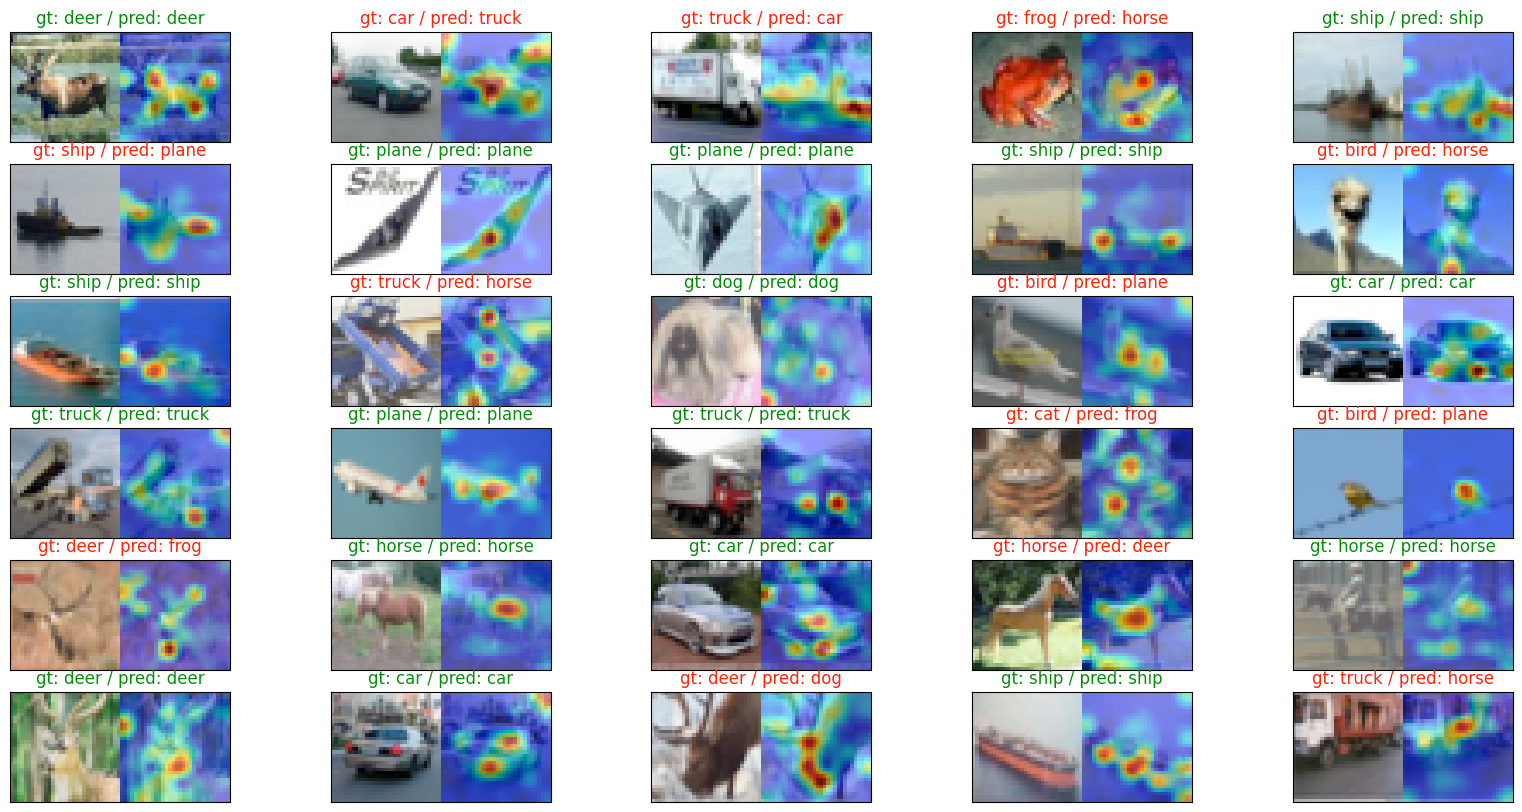

## References

**Architectures**

* Vaswani et al., [*Attention Is All You Need*](https://arxiv.org/abs/1706.03762) — the original Transformer architecture for NLP.
* Dosovitskiy et al., [*An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*](https://arxiv.org/abs/2010.11929) — the original Vision Transformer paper.
* Steiner et al., [*How to train your ViT? Data, Augmentation, and Regularization in Vision Transformers*](https://arxiv.org/pdf/2106.10270.pdf) — large-scale empirical study of training recipes.

**Reference implementations**

* [`google-research/vision_transformer`](https://github.com/google-research/vision_transformer) — the original (JAX) ViT implementation.
* [`rwightman/pytorch-image-models` (timm)](https://github.com/rwightman/pytorch-image-models/blob/master/timm/models/vision_transformer.py) — a high-quality PyTorch re-implementation.

**Regularization and augmentation**

* Huang et al., [*Deep Networks with Stochastic Depth*](https://arxiv.org/pdf/1603.09382.pdf) — stochastic depth / DropPath.
* DeVries & Taylor, [*Improved Regularization of Convolutional Neural Networks with Cutout*](https://arxiv.org/abs/1708.04552) — Cutout.
* Zhang et al., [*mixup: Beyond Empirical Risk Minimization*](https://arxiv.org/abs/1710.09412) — Mixup.
* Yun et al., [*CutMix: Regularization Strategy to Train Strong Classifiers with Localizable Features*](https://arxiv.org/pdf/1905.04899.pdf) — CutMix.
* Cubuk et al., [*RandAugment: Practical Automated Data Augmentation with a Reduced Search Space*](https://arxiv.org/pdf/1909.13719.pdf) — RandAugment.

**Optimization**

* Loshchilov & Hutter, [*SGDR: Stochastic Gradient Descent with Warm Restarts*](https://arxiv.org/abs/1608.03983v5) — cosine annealing learning rate schedule.

**Bonus (intuition)**

* 3Blue1Brown, [*Attention in transformers, step-by-step*](https://www.youtube.com/watch?v=eMlx5fFNoYc).